# Broadband pixel search
- basic notebook that samples IPTA MDC1 using discovery (pixel search) -- new specspat formalism

In [1]:
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
import re
import inspect
import types
import typing
from collections.abc import Iterable
import functools
from pprint import pprint
import time

import numpy as np
import scipy.interpolate as si
import jax
from jax.scipy import stats as jss
import jax.numpy as jnp

from discovery import matrix
from discovery import const
import discovery as ds
import discovery.samplers.numpyro as ds_numpyro
import glob
import discovery.anis_coefficients as dac
import matplotlib.pyplot as plt
from discovery.glgp_specspat import makeglobalgp_fourier_specspat

/home/levis/miniforge3/envs/jhp_disco/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# sampling items
from numpyro import infer, distributions as dist
import numpyro
import scipy.stats as stats
import healpy as hp
from corner import corner
#import maps
import pandas as pd
import pyarrow.feather as feather
import enterprise.signals.anis_coefficients as ac
from PTMCMCSampler import PTMCMCSampler
import matplotlib.patches as mpatches

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
from defiant.extra import mdc1_utils
mdcpsrs, injparams = mdc1_utils.get_MDC1_psrs(use_pickle=True)

## model set up

In [11]:
psrs = mdcpsrs
T = ds.getspan(psrs)
comps = 2 # freq components
lmx = 2
nsi=1

ndict = {f'{p.name}_efac': 1.0 for p in psrs}
ndict.update({f'{p.name}_log10_t2equad': -7 for p in psrs})


psrpos = np.array([p.pos for p in psrs])

aniso_orfs = []
nanisopars = []

pixorf = dac.get_pixsearch_orf(psrpos)
aniso_orfs.append(pixorf)
nanisopars.append(2)


glgp_mdc = makeglobalgp_fourier_specspat(psrs, [ds.powerlaw],
                                    [aniso_orfs],
                                    components=comps, T=T, name='gw', nbasis=[nanisopars])


m_mdc = ds.ArrayLikelihood([ds.PulsarLikelihood([psr.residuals,
                                             ds.makenoise_measurement_simple(psr, noisedict=ndict),
                                             ds.makegp_timing(psr, svd=True)]) for psr in psrs],
                       commongp = ds.makecommongp_fourier(psrs, ds.powerlaw, components=30, T=T, name='rednoise'),
                       globalgp = glgp_mdc)

# m_mdc = ds.GlobalLikelihood([ds.PulsarLikelihood([psr.residuals, #ds.makenoise_measurement_simple(psr, noisedict=ndict),
#                                              ds.makenoise_measurement_simple(psr),
#                                              ds.makegp_timing(psr, svd=True),
#                                              ds.makegp_fourier(psr, ds.powerlaw, components=30, name='rednoise')]) for psr in psrs],
#                                              globalgp = glgp_mdc)


mdc_jlogl = jax.jit(m_mdc.logL)

@jax.jit
def constrn_like(params):
    paramdict = {f'{p.name}_rednoise_gamma':1 for p in mdcpsrs}
    paramdict.update({f'{p.name}_rednoise_log10_A':-18 for p in mdcpsrs})
    paramdict[f'gw_gwcostheta_gwphi(2)'] = params[:-2]
    paramdict['gw_gamma'] = params[-2]
    paramdict['gw_log10_A'] = params[-1]
    return m_mdc.logL(paramdict)


    

In [12]:
mdc_jlogl.params

['J0030+0451_rednoise_gamma',
 'J0030+0451_rednoise_log10_A',
 'J0218+4232_rednoise_gamma',
 'J0218+4232_rednoise_log10_A',
 'J0437-4715_rednoise_gamma',
 'J0437-4715_rednoise_log10_A',
 'J0613-0200_rednoise_gamma',
 'J0613-0200_rednoise_log10_A',
 'J0621+1002_rednoise_gamma',
 'J0621+1002_rednoise_log10_A',
 'J0711-6830_rednoise_gamma',
 'J0711-6830_rednoise_log10_A',
 'J0751+1807_rednoise_gamma',
 'J0751+1807_rednoise_log10_A',
 'J0900-3144_rednoise_gamma',
 'J0900-3144_rednoise_log10_A',
 'J1012+5307_rednoise_gamma',
 'J1012+5307_rednoise_log10_A',
 'J1022+1001_rednoise_gamma',
 'J1022+1001_rednoise_log10_A',
 'J1024-0719_rednoise_gamma',
 'J1024-0719_rednoise_log10_A',
 'J1045-4509_rednoise_gamma',
 'J1045-4509_rednoise_log10_A',
 'J1455-3330_rednoise_gamma',
 'J1455-3330_rednoise_log10_A',
 'J1600-3053_rednoise_gamma',
 'J1600-3053_rednoise_log10_A',
 'J1603-7202_rednoise_gamma',
 'J1603-7202_rednoise_log10_A',
 'J1640+2224_rednoise_gamma',
 'J1640+2224_rednoise_log10_A',
 'J1643-

In [13]:
numallaniparams = sum(nanisopars)
tstpars = jnp.zeros(numallaniparams + comps)
tstpars = tstpars.at[-comps:].set(np.ones(comps)*-6.0)
# tstpars = tstpars.at[-2].set(-7)
# tstpars = tstpars.at[-1].set(-6)

constrn_like(tstpars)

Array(39601.1811363, dtype=float64)

In [14]:
nparams = np.sum(nanisopars) + comps

In [15]:
nparams


np.int64(4)

In [16]:
%timeit constrn_like(tstpars).block_until_ready()

1.95 ms ± 27 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [28]:
l10apri = lambda x: jss.uniform.logpdf(x, -18, 6)
gampri = lambda x: jss.uniform.logpdf(x, 0, 7)
costpri = lambda x: jss.uniform.logpdf(x, -1, 2)
phipri = lambda x: jss.uniform.logpdf(x, 0, 2*jnp.pi)


@jax.jit
def priorfunc(params):
    costhetaprival = costpri(params[0])
    phiprival = phipri(params[1])
    A10prival = l10apri(params[-1])
    gamprival = gampri(params[-2])
    fullpri = gamprival + A10prival + costhetaprival + phiprival
    #fullpri = phiprival 

    return fullpri

tstpars = [0.1, 0.1, 4.3333, -15]
priorfunc(tstpars)

Array(-6.26869387, dtype=float64, weak_type=True)

In [29]:
%timeit priorfunc(tstpars).block_until_ready()

42.8 μs ± 471 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [30]:
prigrad = jax.grad(priorfunc)
likgrad = jax.grad(constrn_like)

# prigradjump = lambda x: (priorfunc(x), prigrad(x))
# prigradlike = lambda x: (constrn_like(x), likgrad(x))

def prigradjump(x):
    return np.float64(priorfunc(x)).item(), np.array(prigrad(x))

def likegradjump(x):
    return np.float64(constrn_like(x)).item(), np.array(likgrad(x))

In [31]:

initcov = np.eye(nparams) * 0.01
# sampler = PTMCMCSampler.PTSampler(ndim=nparams, logl=constrn_like, logp=priorfunc,
#                                    logl_grad=likegradjump, logp_grad=prigradjump, cov=initcov,
#                                    outDir=f'./chains/narrow_lm{lmx}_{comps}f_gradjptst/', resume=False)


sampler = PTMCMCSampler.PTSampler(ndim=nparams, logl=constrn_like, logp=priorfunc, cov=initcov,
                                   outDir=f'./chains/pixsearch_broad_{comps}f/', resume=False)

# def nothinglnlike(x):
#     return 1.0


#         bl0prival = bl0pri(blms[m0ampidx])
#         blmamp_prival = blm_amp_pri(blms[lmampidx])
#         blmphs_prival = blm_phase_pri(blms[lmphsidx])


# def draw_from_blm_prior(x, iter, beta):
#     '''Getting draws from blm prior'''
#     # key = jax.random.PRNGKey(iter)
#     q = x.copy()
#     # q = jnp.array(x)
    
#     lqxy = 0

#     aniparamct = 0 # LSS we do this in case we do not have the same number of clms for each freq component
#     full_blmprival = 0 # LSS a placeholder for the sum of the clm priors
#     for c in range(comps):
#             q[m0ampidx] = np.random.uniform(low=0, high=50, size=len(m0ampidx))
#         q[lmampidx] = np.random.uniform(low=0, high=50, size=len(lmampidx))
#         q[lmphsidx] = np.random.uniform(low=0, high=2*np.pi, size=len(lmphsidx))

#         blms = params[aniparamct:aniparamct+nblms[c]]
#         bl0prival = bl0pri(blms[m0ampidx])
#         blmamp_prival = blm_amp_pri(blms[lmampidx])
#         blmphs_prival = blm_phase_pri(blms[lmphsidx])
#         blmprival = np.sum(bl0prival) + np.sum(blmamp_prival) + np.sum(blmphs_prival)
#         full_blmprival += blmprival
#         aniparamct += nblms[c]


#     # LSS choose random clm - hardcoded what number params this corresponds to
#     #randclm = np.random.choice(numberofclms)
#     # q = q.at[randclm].set(jax.random.uniform(key, minval=-3, maxval=3))
#     q[m0ampidx] = np.random.uniform(low=0, high=50, size=len(m0ampidx))
#     q[lmampidx] = np.random.uniform(low=0, high=50, size=len(lmampidx))
#     q[lmphsidx] = np.random.uniform(low=0, high=2*np.pi, size=len(lmphsidx))


#     lqxy = clmpri(q) - clmpri(x)  # log proposal ratio for Metropolis-Hastings
#     #lqxy = lqxy.at[-comps:].set(rhopri(q[-comps:]) - rhopri(x[-comps:]))
#     lqxy = np.array(lqxy)
#     lqxy[-comps:] = np.zeros(comps)
#     return q, np.sum(lqxy)

# # def drawclmpri_wrap(x, iter, beta):
# #     return np.array(draw_from_clm_prior(x, iter, beta))

# # sampler.addProposalToCycle(draw_from_clm_prior, 50)

In [32]:
jax.devices()

[CudaDevice(id=0)]

In [33]:
tstpars = [0.1, 0.1, 4.3333, -15]
tstpars = np.array(tstpars)
print(tstpars)

sampler.sample(Niter=100000, p0=np.array(tstpars),
               SCAMweight=0, AMweight=25, DEweight=50)

[  0.1      0.1      4.3333 -15.    ]
Finished 10.00 percent in 13.059526 s Acceptance rate = 0.050911Adding DE jump with weight 50
Finished 100.00 percent in 140.436283 s Acceptance rate = 0.30601
Run Complete


## Looking at the chain

In [34]:
chn = np.loadtxt(f'/home/levis/ipta_aniso_datachallenge/examples/pixelsearch/chains/pixsearch_broad_{comps}f/chain_1.txt')
# chn = np.loadtxt(f'/home/levis/ipta_aniso_datachallenge/examples/chains/priordrawtst/chain_1.txt')

In [35]:
chn.shape

(10001, 8)

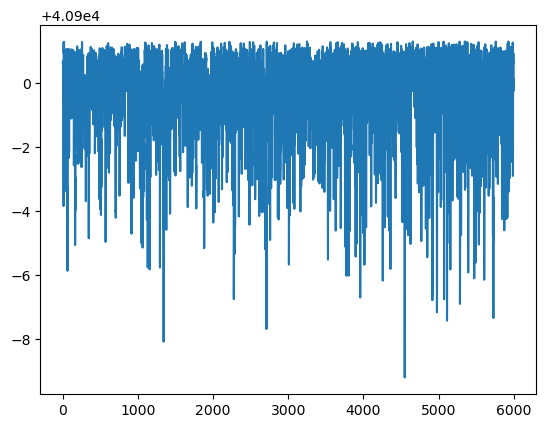

In [43]:
plt.plot(chn[4000:, -4])

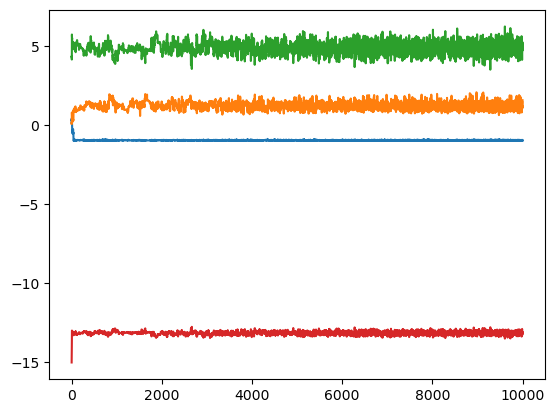

In [37]:

for i in range(nparams):
    plt.plot(chn[:, i])  

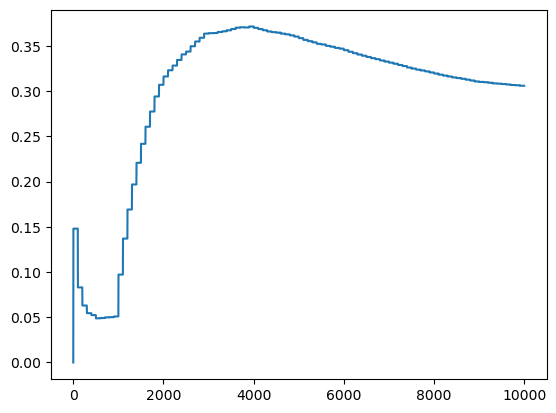

In [38]:
plt.plot(chn[:, -2])

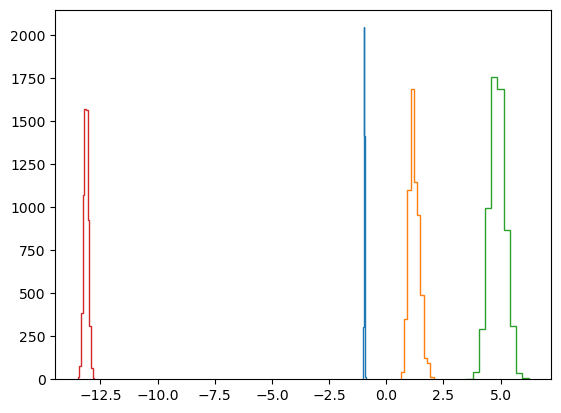

In [41]:
for i in range(nparams):
    plt.hist(chn[4000:, i], histtype='step')

plt.show()

In [48]:
chn.shape

(10001, 10)

1000


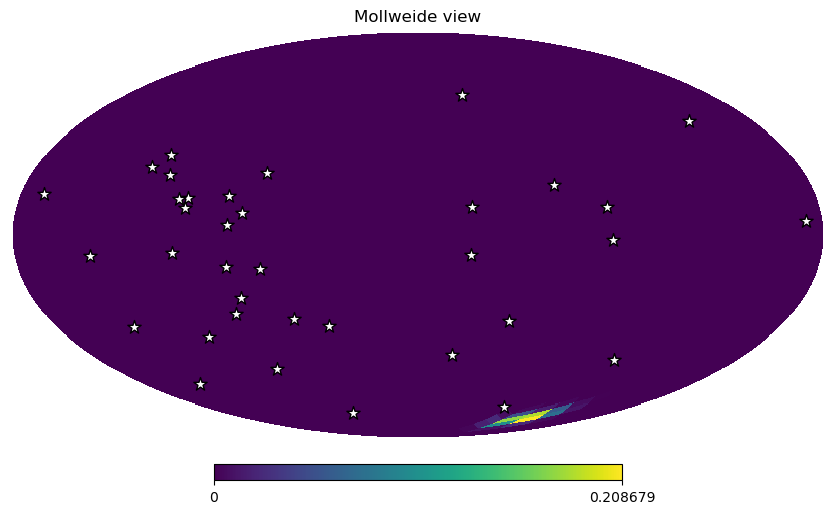

In [42]:
nsi = 16
aniparamct = 0
smaps = []

for i in np.random.randint(4000, chn.shape[0], 1000):
    smaps.append(dac.chain_skymap(theta=chn[:, 0], phi=chn[:, 1],ct=True, nside=nsi))
print(len(smaps))
hp.mollview(np.median(smaps, axis=0), rot=180)
dac.plot_pulsars(psrs)
plt.show()
